# Loan Approved Dataset

Step 0 - Importing Libraries :

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)


**Step 1 - Data Collection**

In [4]:
data = pd.read_csv(r"C:\Users\mainu\Desktop\Loan Price Prediction\loan_approved.csv")



In [5]:
df=data.copy()

In [6]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


Step 2 - EDA (Data Understanding)

In [7]:
df.shape

(614, 13)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Loan_ID                 614 non-null    object 
 1   Gender                  601 non-null    object 
 2   Married                 611 non-null    object 
 3   Dependents              599 non-null    object 
 4   Education               614 non-null    object 
 5   Self_Employed           582 non-null    object 
 6   ApplicantIncome         614 non-null    int64  
 7   CoapplicantIncome       614 non-null    float64
 8   LoanAmount              592 non-null    float64
 9   Loan_Amount_Term        600 non-null    float64
 10  Credit_History          564 non-null    float64
 11  Property_Area           614 non-null    object 
 12  Loan_Status (Approved)  614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [9]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [10]:
df.describe(include=['O'])

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status (Approved)
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP001002,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422


In [11]:
#checking null values

df.isnull().sum()

Loan_ID                    0
Gender                    13
Married                    3
Dependents                15
Education                  0
Self_Employed             32
ApplicantIncome            0
CoapplicantIncome          0
LoanAmount                22
Loan_Amount_Term          14
Credit_History            50
Property_Area              0
Loan_Status (Approved)     0
dtype: int64

In [12]:
df.isnull().sum().sum()

np.int64(149)

In [13]:
# percentage of null values
print((df.isnull().sum().sum()/len(df))*100)

24.267100977198698


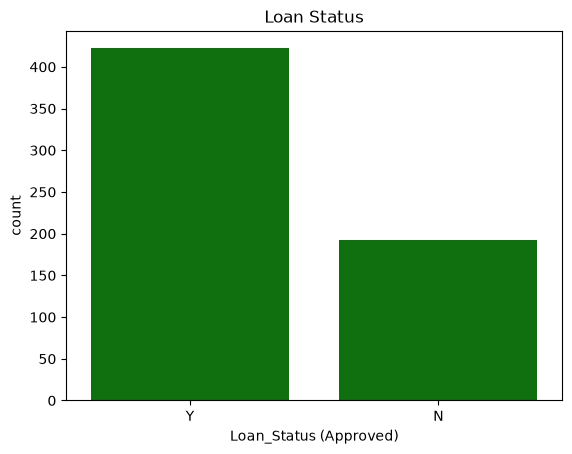

In [14]:
#Checking Target Distribution

sns.countplot(data=df, x='Loan_Status (Approved)',color='green')
plt.title("Loan Status")
plt.show()

In [15]:
# Numerical and Categorical Columns

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

In [16]:
print(num_cols)

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')


In [17]:
print(cat_cols)

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'Property_Area', 'Loan_Status (Approved)'],
      dtype='object')


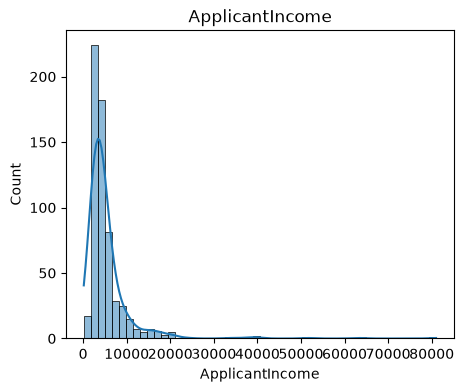

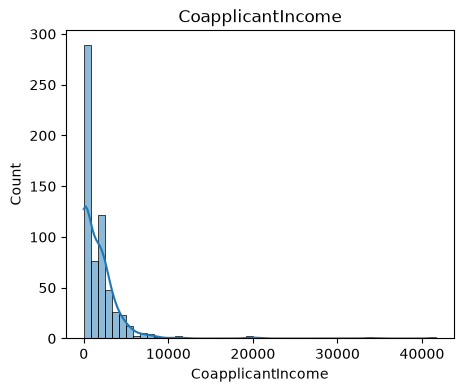

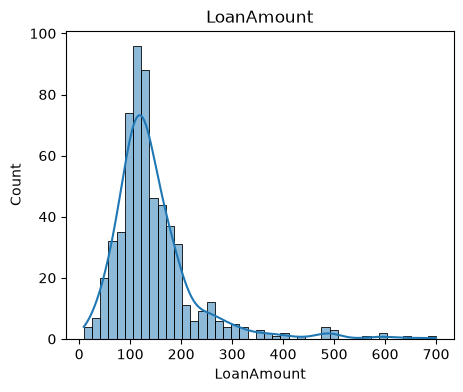

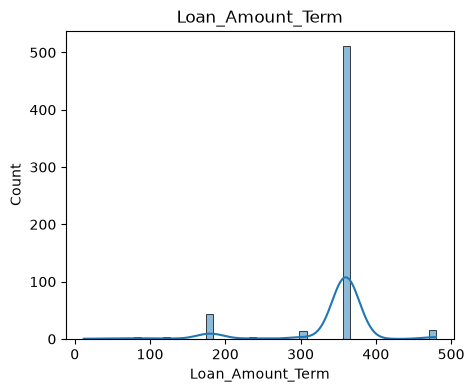

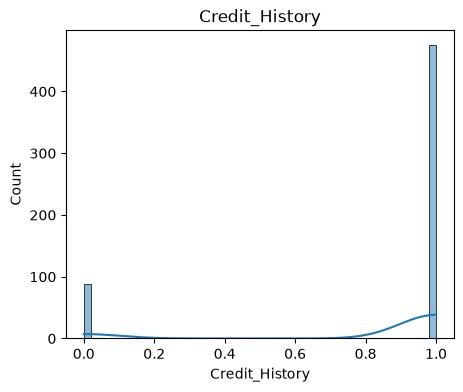

In [18]:
#Uni Variate Analysis

for col in num_cols:
    plt.figure(figsize=(5,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()



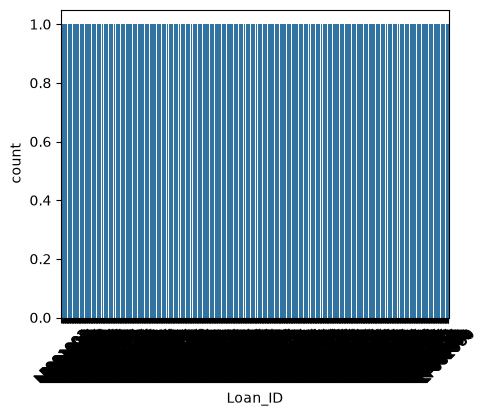

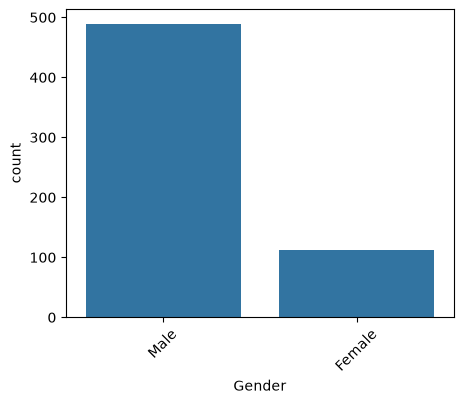

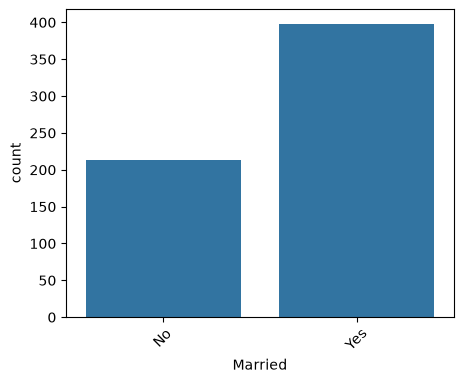

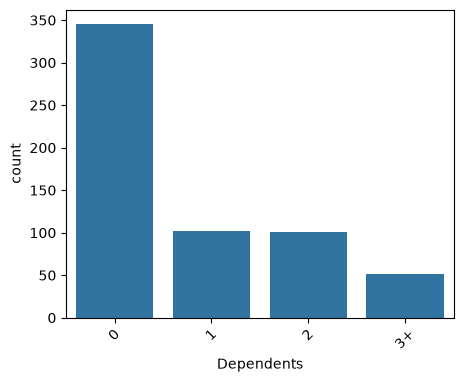

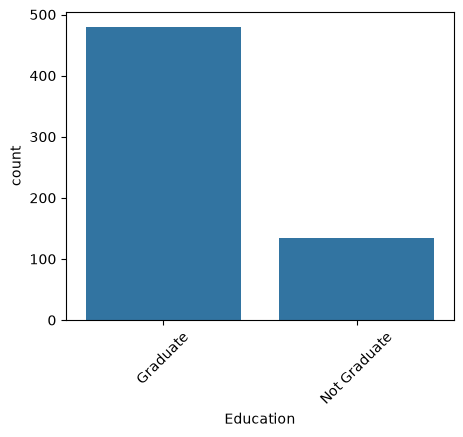

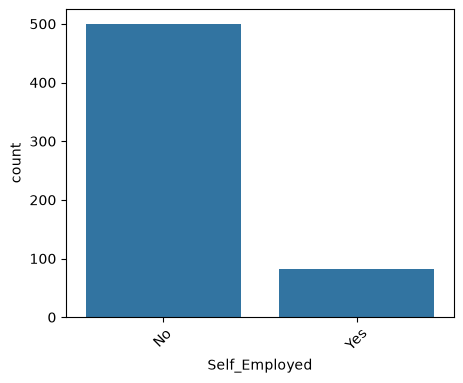

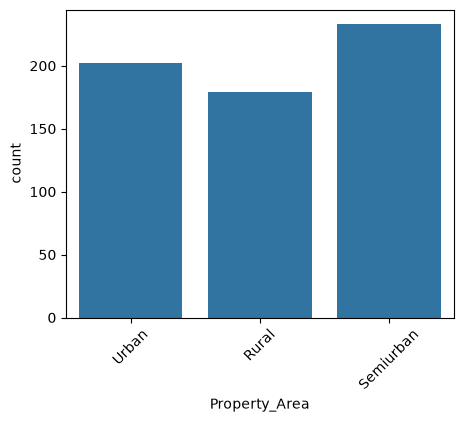

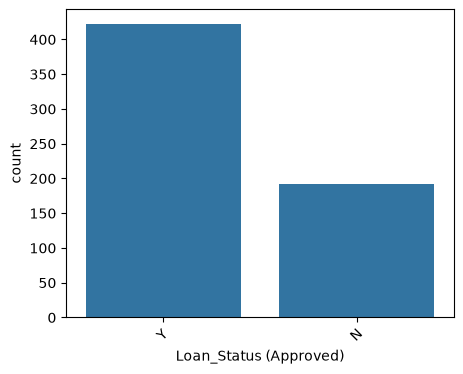

In [19]:
for col in cat_cols:
    plt.figure(figsize=(5,4))
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=45)
    plt.show()

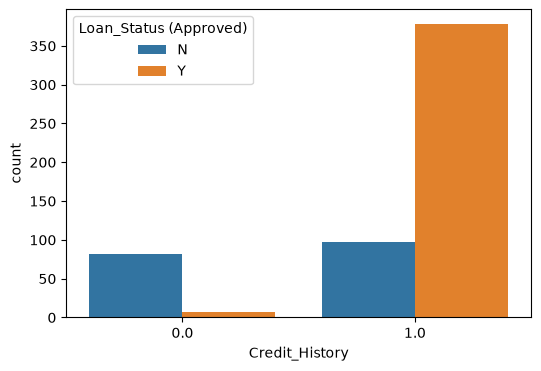

In [20]:
# Bivariate Analysis
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Credit_History', hue='Loan_Status (Approved)')
plt.show()

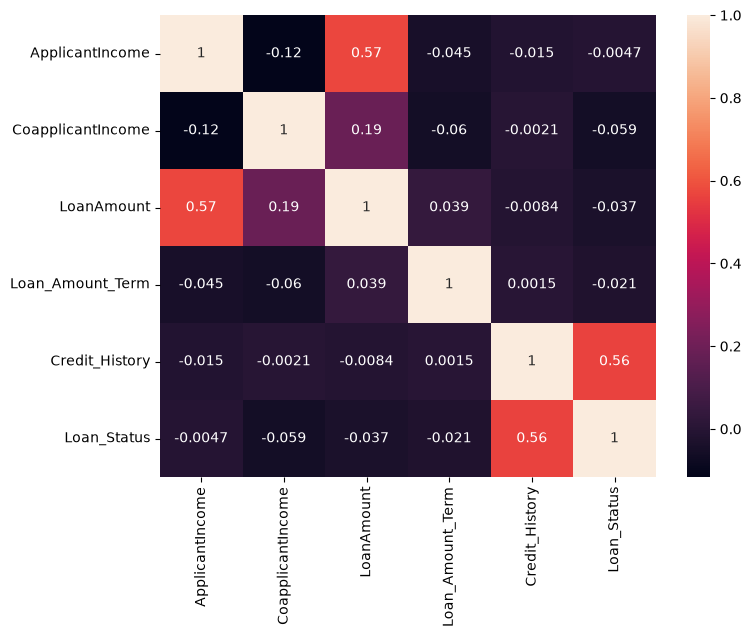

In [21]:
# Correlation
df['Loan_Status'] = df['Loan_Status (Approved)'].map({'N':0,'Y':1})
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()


**Step 3 : Feature Engineering**

In [22]:
# Feature Engineering

df['Dependents'] = df['Dependents'].replace('3+','3')


In [23]:
type(df['Dependents'])

pandas.core.series.Series

In [24]:
df['Dependents'] = pd.to_numeric(df['Dependents'])



In [25]:
type(df['Dependents'])

pandas.core.series.Series

In [26]:
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df['EMI'] = (df['LoanAmount']*1000)/360
df['Income_Per_Person'] = df['TotalIncome']/(df['Dependents']+1)

if 'Loan_ID' in df.columns:
    df.drop('Loan_ID', axis=1, inplace=True)

**Step 4 : X and y**

In [74]:
X = df.drop(['Loan_Status', 'Loan_Status (Approved)'], axis=1)

y = df['Loan_Status (Approved)']

print(X.columns)

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'TotalIncome',
       'EMI', 'Income_Per_Person'],
      dtype='object')


In [73]:
print(df.columns.tolist())

['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status (Approved)', 'Loan_Status', 'TotalIncome', 'EMI', 'Income_Per_Person']


In [ ]:
y

0      Y
1      N
2      Y
3      Y
4      Y
      ..
609    Y
610    Y
611    Y
612    Y
613    N
Name: Loan_Status (Approved), Length: 614, dtype: object

In [ ]:
X

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,1
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0.0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,1
610,LP002979,Male,Yes,3.0,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,1
611,LP002983,Male,Yes,1.0,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,1
612,LP002984,Male,Yes,2.0,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,1


**Step 5 : Train-Test-Split**

In [75]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

**Step 6 : Preprocessing Pipeline**

In [76]:
num_features = X_train.select_dtypes(include=['int64','float64']).columns
cat_features = X_train.select_dtypes(include=['object']).columns


In [77]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [78]:
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])

In [79]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

**Step 7 : Baseline Models**

In [80]:
models = {"KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

for name, model in models.items():

    pipe = Pipeline([('preprocessor', preprocessor),('model', model)])

    pipe.fit(X_train, y_train)

    pred = pipe.predict(X_test)

    print(name)
    print("Accuracy:", accuracy_score(y_test, pred))
    print()

KNN
Accuracy: 0.8780487804878049

Naive Bayes
Accuracy: 0.8455284552845529



**Step 8 : Hyperparameter Tuning**

In [81]:
from sklearn.model_selection import train_test_split, GridSearchCV

knn_pipeline = Pipeline([('preprocessor', preprocessor),
    ('model', KNeighborsClassifier())
])

In [82]:
param_grid_knn = {
    'model__n_neighbors':[3,5,7,9,11,15],
    'model__weights':['uniform','distance'],
    'model__metric':['euclidean','manhattan']
}

In [83]:
grid_knn = GridSearchCV(
    knn_pipeline,param_grid_knn,cv=5,scoring='accuracy',n_jobs=-1)

In [84]:
grid_knn.fit(X_train,y_train)

print("Best KNN Parameters:")
print(grid_knn.best_params_)

print("Best KNN CV Score:")
print(grid_knn.best_score_)

Best KNN Parameters:
{'model__metric': 'euclidean', 'model__n_neighbors': 7, 'model__weights': 'uniform'}
Best KNN CV Score:
0.7902288188002473


In [85]:
# HP Tuning for NB

nb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GaussianNB())])

In [86]:
param_grid_nb = {
    'model__var_smoothing':np.logspace(0,-9,100)
}

In [87]:
grid_nb = GridSearchCV(
    nb_pipeline,
    param_grid_nb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [88]:
grid_nb.fit(X_train,y_train)

print("Best NB Parameters:")
print(grid_nb.best_params_)

print("Best NB CV Score:")
print(grid_nb.best_score_)

Best NB Parameters:
{'model__var_smoothing': np.float64(0.1)}
Best NB CV Score:
0.7963512677798391


**Step 9 : Model Evaluation**

In [89]:
#KNN

best_knn = grid_knn.best_estimator_

In [90]:
knn_pred = best_knn.predict(X_test)

In [91]:
print("KNN Accuracy:")
print(accuracy_score(y_test,knn_pred))

KNN Accuracy:
0.8536585365853658


In [92]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print(classification_report(y_test,knn_pred))

              precision    recall  f1-score   support

           N       0.95      0.55      0.70        38
           Y       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123



In [93]:
print(confusion_matrix(y_test,knn_pred))

[[21 17]
 [ 1 84]]


In [94]:
knn_prob = best_knn.predict_proba(X_test)[:,1] #predicts probability of each class for all samples , especially giving second column,helpful for roc auc

In [95]:
print("KNN ROC-AUC:")
print(roc_auc_score(y_test,knn_prob))

KNN ROC-AUC:
0.7726006191950465


In [96]:
# Naive Baye's

best_nb = grid_nb.best_estimator_

In [97]:
nb_pred = best_nb.predict(X_test)

In [98]:
print("NB Accuracy:")
print(accuracy_score(y_test,nb_pred))


NB Accuracy:
0.8455284552845529


In [99]:
print(classification_report(y_test,nb_pred))

              precision    recall  f1-score   support

           N       0.88      0.58      0.70        38
           Y       0.84      0.96      0.90        85

    accuracy                           0.85       123
   macro avg       0.86      0.77      0.80       123
weighted avg       0.85      0.85      0.84       123



In [100]:
print(confusion_matrix(y_test,nb_pred))



[[22 16]
 [ 3 82]]


In [101]:
nb_prob = best_nb.predict_proba(X_test)[:,1]



In [59]:
nb_prob

array([5.10117298e-32, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
       1.00000000e+00, 1.65063383e-22, 1.00000000e+00, 1.00000000e+00,
       1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
       1.00000000e+00, 1.00000000e+00, 1.43634984e-31, 1.20849994e-31,
       1.00000000e+00, 2.73434675e-31, 1.15553355e-31, 1.00000000e+00,
       1.30751185e-31, 1.00000000e+00, 6.54892994e-63, 1.00000000e+00,
       1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
       1.85958855e-31, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
       1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
       1.00000000e+00, 1.00000000e+00, 8.06325480e-23, 1.00000000e+00,
       2.17944275e-22, 1.00000000e+00, 1.13755983e-22, 1.00000000e+00,
       1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 8.56156730e-22,
       1.00000000e+00, 1.00000000e+00, 1.26653599e-31, 1.00000000e+00,
       2.58386247e-32, 1.00000000e+00, 2.52131684e-23, 4.31665105e-23,
      

In [102]:
print("NB ROC-AUC:")
print(roc_auc_score(y_test,nb_prob))

NB ROC-AUC:
0.8046439628482973


 **Step 10 : Best Model Selection**

In [103]:
knn_acc = accuracy_score(
    y_test,
    best_knn.predict(X_test)
)

In [104]:
knn_acc

0.8536585365853658

In [105]:
nb_acc = accuracy_score(
    y_test,
    best_nb.predict(X_test)
)

In [106]:
nb_acc

0.8455284552845529

In [107]:
if knn_acc > nb_acc:
    best_model = best_knn
    print("Best Model = KNN")
else:
    best_model = best_nb
    print("Best Model = Naive Bayes")

Best Model = KNN


**Step 11 : Save Complete Pipeline**

In [108]:
import joblib

joblib.dump(best_model,"loan_pipeline.pkl")

['loan_pipeline.pkl']

In [109]:
import joblib

model = joblib.load("loan_pipeline.pkl")

print(model.named_steps['preprocessor'].feature_names_in_)

['Gender' 'Married' 'Dependents' 'Education' 'Self_Employed'
 'ApplicantIncome' 'CoapplicantIncome' 'LoanAmount' 'Loan_Amount_Term'
 'Credit_History' 'Property_Area' 'TotalIncome' 'EMI' 'Income_Per_Person']


In [111]:
import joblib

model = joblib.load("loan_pipeline.pkl")

print(model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Dependents', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'TotalIncome', 'EMI',
       'Income_Per_Person'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder'

In [112]:
import joblib

joblib.dump(best_model, "loan_pipeline.pkl")

['loan_pipeline.pkl']

**Step 12 : Deployment(Streamlit Template)**

In [ ]:
!pip install streamlit

In [ ]:
import os
print(os.listdir())

['app.py', 'loan price prediction.ipynb', 'loan_approved.csv', 'loan_pipeline.pkl', 'requirements.txt', 'venv']


In [ ]:
model

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[154.,337.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.31,0.69]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[<U1](2,)","['N','Y']"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1e-09
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,509
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 509)","[[-0.04, 0.02, 0.07,..., 0.37, 0.27, 0.36], [ 0.02,-0.01,-0.03,..., 0.26, 0.42, 0.31]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 509)","[[0.98,1.3 ,2.08,...,0.23,0.2 ,0.23], [1.01,0.86,0.5 ,...,0.19,0.24,0.22]]"


In [ ]:
'''
Refer Streamlit Deployment Discussion as a continuation

st.title("Loan Approval Prediction")

'''

'\nRefer Streamlit Deployment Discussion as a continuation\n\nst.title("Loan Approval Prediction")\n\n'